## Task 2

In [10]:
%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

In [4]:
import numpy as np

random_generator = np.random.default_rng(42)
dataset_size = 250
inputs_raw = random_generator.uniform(-3, 3, size=(dataset_size, 1))
outputs = (
    1.1
    - 5.0 * inputs_raw
    + 0.5 * (inputs_raw**2)
    + 0.3 * (inputs_raw**3)
    + random_generator.standard_normal(size=(dataset_size, 1)) * 1.2
)


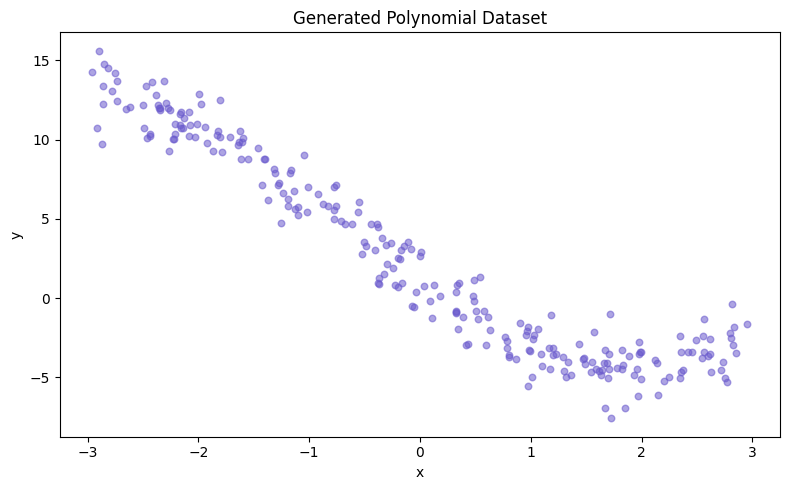

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(inputs_raw, outputs, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from shared import add_bias_term_to_inputs

degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
scaler = StandardScaler()
inputs_with_polynomial_features = scaler.fit_transform(
    poly.fit_transform(inputs_raw)
)
inputs = add_bias_term_to_inputs(inputs_with_polynomial_features)

In [8]:
from shared import (
    train_weights,
    add_bias_term_to_inputs,
)
from shared.gradient import stochastic
epochs = 400
results_simple = []
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}

for learning_rate in learning_rates:
    batch_result = train_weights(
        inputs,
        initial_weights=np.zeros((inputs.shape[1], 1)),
        outputs=outputs,
        epochs=epochs,
        compute_new_weights_function=stochastic.create_compute_new_weights_function(
            learning_rate=learning_rate,
            random_generator=random_generator
        )
    )
    sgd_histories[learning_rate] = batch_result


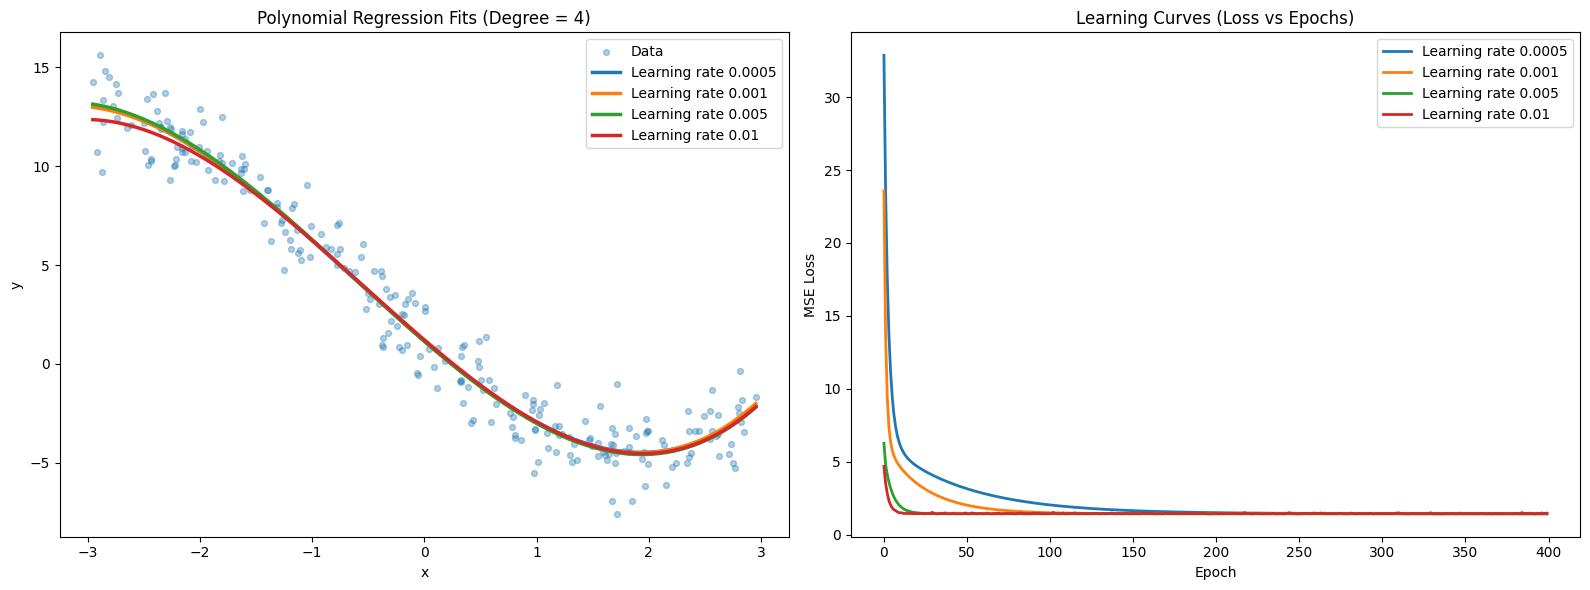

In [9]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(inputs_raw.min(), inputs_raw.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(inputs_raw, outputs, alpha=0.35, s=18, label="Data")
for learning_rate, result in sgd_histories.items():
    axes[0].plot(x_grid, X_grid_design @ result.weights, linewidth=2.5, label=f"Learning rate {learning_rate}")

axes[0].set_title("Polynomial Regression Fits (Degree = 4)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

for learning_rate, result in sgd_histories.items():
    axes[1].plot(result.loss_history, linewidth=2, label=f"Learning rate {learning_rate}")

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()